# Classifying Banking Intent from Customer Queries

### Introduction

In this project, we aim to build an end-to-end pipeline for banking intent classification. The main objective is to categorize customer queries into 77 distinct banking-related intents, ranging from card issues to payment inquiries.

We are going to develop and compare two specific models:

- **The Baseline:** A Multi-Layer Perceptron (MLP), which serves as our fast and simple starting point.

- **The Advanced Model:** A RoBERTa model, fine-tuned with LoRA. This approach helps us get deep understanding from a large model without needing massive computing power.

By testing both, we want to find out if the jump in performance from a basic model to a modern transformer is worth the extra complexity in a real-world banking setup.

### Project Goals

- **Data Exploration:** We plan to perform a comprehensive Exploratory Data Analysis on the Banking77 dataset. This involves investigating the distribution of intents, analyzing sentence structures, and identifying key linguistic patterns that define different customer needs.

- **Model Training & Comparison:** We are going to train both models on the same data. This will allow us to compare their overall performance and understand the trade-offs between a lightweight architecture and a deep transformer model.

- **Model Evaluation:** Beyond simple accuracy, we will conduct a detailed performance analysis to understand how our models behave across different intents. This evaluation will help us identify specific strengths and weaknesses, showing us where the models excel and where they might struggle with overlapping categories.

- **Secure Predictions:** We intend to create a safe way to test the model by adding a PII Redactor. This tool will mask sensitive details like emails or card numbers before the AI even reads the text, making the system much more secure.

### Dataset

The Banking77 dataset consists of ``13,083 (10,003 for training and 3,080 for testing)`` real-world customer queries mapped to 77 distinct intent categories. This dataset is a standard for testing how well models can handle fine-grained text classification in a financial context.

The main challenge lies in the high similarity between many of the labels. This requires the model to understand the specific meaning of each sentence rather than just identifying individual keywords.



---

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
import hashlib

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset
from transformers import DataCollatorWithPadding

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
sns.set_palette("viridis")

torch.manual_seed(42)

---

## Loading and Inspecting the Datasets

We begin by loading and inspecting the ``banking77_train.csv`` and ``banking77_test.csv`` datasets to understand their structure and overall content.

In [ ]:
# load the train file
train = pd.read_csv('datasets/banking77_train.csv')
# load the test file
test = pd.read_csv('datasets/banking77_test.csv')

# show the first 5 rows
display(train.head())
display(test.head())

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      10003 non-null  object
 1   category  10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


**Quick summary and initial observations - Train Set:**

- The training dataset contains ``10,003 samples`` and ``2 columns``, both stored as ``object`` data types.

- The ``text`` and ``category`` columns are fully populated, indicating that there are ``no missing values`` in the dataset.

- Since both features are text-based, the data must be transformed into numerical representations before model training. The input queries will require appropriate ``text vectorization or tokenization strategies``, while the intent labels must be ``encoded`` for supervised learning.

In summary, the dataset is well-organized and structurally sound, making it suitable for building and evaluating a multi-class intent classification system using both traditional and transformer-based approaches.

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3080 entries, 0 to 3079
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      3080 non-null   object
 1   category  3080 non-null   object
dtypes: object(2)
memory usage: 48.3+ KB


**Quick summary and initial observations - Test Set:**

- The test dataset consists of ``3,080 samples`` and ``2 columns``, both stored as ``object`` data types.

- There are ``no null values`` in either the text or category columns, indicating that the dataset is clean and structurally consistent with the training set.

- When compared to the training dataset, the split corresponds to an approximate ``76%–24%`` train–test ratio. This proportion is generally appropriate for supervised learning tasks, as it allows sufficient data for model training while maintaining a reliable subset for evaluating generalization performance.

Overall, the dataset split appears appropriate for evaluating generalization performance in a multi-class intent classification task.

In [ ]:
train.describe()

,text,category
count,10003,10003
unique,10003,77
top,Which countries are represented?,card_payment_fee_charged
freq,1,187


**Descriptive summary:**

- The training dataset contains ``10,003 text samples`` distributed across ``77`` unique intent categories.

- Each text entry is ``unique``, indicating that there are ``no duplicate queries`` in the training set. This is beneficial for model generalization, as the model is exposed to diverse linguistic patterns rather than repeated inputs.

- The target variable consists of 77 distinct intent classes. The most frequent class, ``card_payment_fee_charged``, appears ``187 times``, suggesting that the dataset likely exhibits ``class imbalance``. Given the multi-class nature of the task, this imbalance may impact per-class performance and should be carefully considered during evaluation, particularly when selecting appropriate metrics such as macro-averaged F1-score.


---

## Data Exploration and Visualization

**What Is the Distribution of the Category Column and How Does It Affect Model Training?**

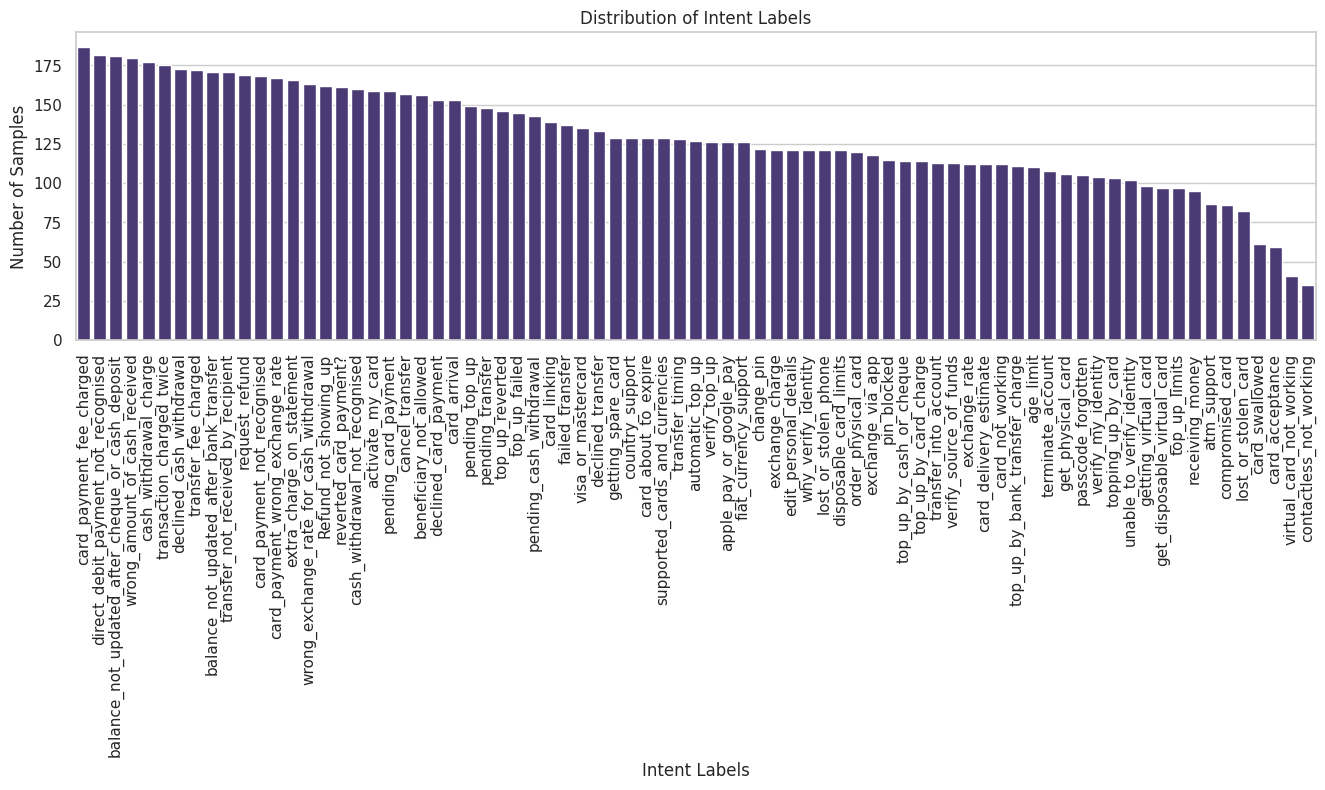

In [ ]:
class_counts = train['category'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16,4))

sns.barplot(x=class_counts.index,y=class_counts.values)

plt.title("Distribution of Intent Labels")
plt.xlabel("Intent Labels")
plt.ylabel("Number of Samples")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The category distribution plot reveals a clear ``long-tail pattern`` across the 77 intent classes. A small number of categories contain relatively high sample counts (near 187), while many classes have progressively fewer samples (around 30-40).

This imbalance suggests that the classification task is ``not uniformly distributed``, which may introduce bias toward majority classes during model training. Models trained on such data may tend to favor frequently occurring intents, potentially reducing predictive performance on minority classes.

From a modeling perspective, this characteristic emphasizes the importance of using evaluation metrics such as ``macro-averaged F1-score`` rather than relying solely on accuracy. Additionally, techniques such as ``class weighting, balanced loss functions, or parameter-efficient fine-tuning (LoRA)`` approaches may help mitigate imbalance-related performance degradation.

Overall, the distribution indicates that the dataset represents a realistic multi-intent customer query environment but introduces moderate class imbalance challenges that should be considered during model development and evaluation.

**What is the Word Count Distribution of Texts?**

In [ ]:
train['word_count'] = train['text'].str.split().str.len()

text_word_count = train['word_count'].describe()
text_word_count

,word_count
count,10003.000000
mean,11.949415
std,7.891577
min,2.000000
25%,7.000000
50%,10.000000
75%,13.000000
max,79.000000


The word count analysis reveals that customer queries are generally concise, with an ``average length of 11.9 words``. The data is heavily concentrated within a narrow range, where the majority of queries consist of ``7 to 13 words``. This indicates that users typically express their banking needs in short, direct sentences rather than long, complex paragraphs.

However, the dataset also contains significant outliers, ranging from minimal ``2-word`` requests to much longer ``79-word`` explanations. This variance is a critical observation for the modeling phase; while most inputs are brief, the model must still be robust enough to handle detailed descriptions.

The brevity of the majority suggests a high-signal environment with very little ``"filler"`` text. This means the model must be highly sensitive to key functional words to accurately capture intent.

Overall, this distribution provides a clean and direct dataset that is well-suited for both traditional and transformer-based architectures.

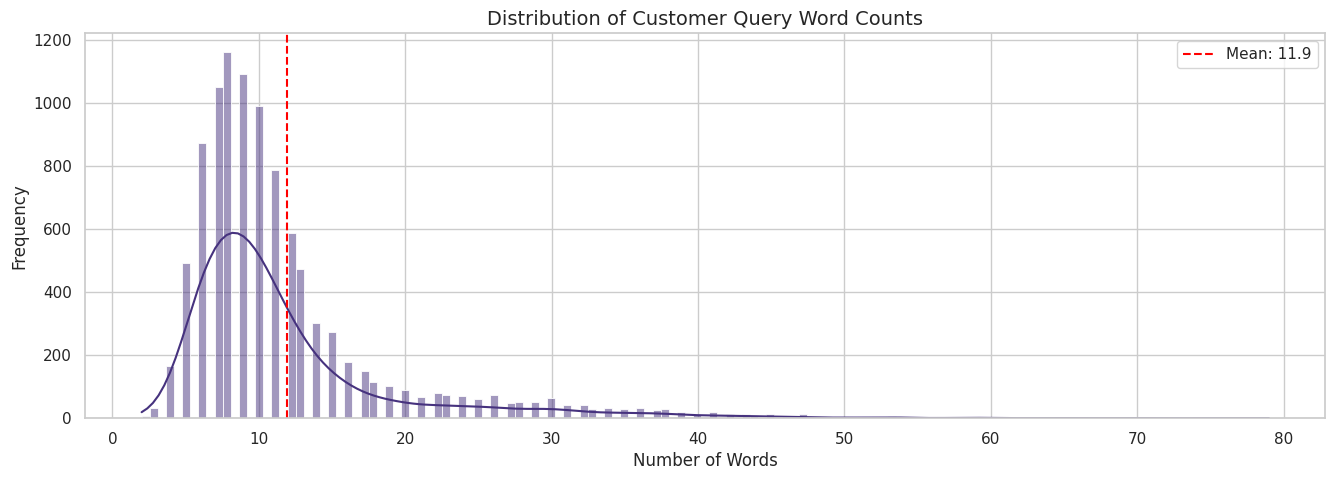

In [ ]:
plt.figure(figsize=(16, 5))
sns.histplot(train['word_count'], kde=True)

plt.title('Distribution of Customer Query Word Counts', fontsize=14)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.axvline(x=text_word_count['mean'],color='red',linestyle='--',label=f"Mean: {text_word_count['mean']:.1f}")

plt.legend()
plt.show()

The histogram visualizes a distinct ``right-skewed`` distribution, where the frequency of queries peaks sharply at the lower end of the scale. This visual trend confirms that the vast majority of users prefer brevity, communicating their banking needs in very short, punchy sentences rather than lengthy descriptions.

The graph also highlights a persistent ``"tail"`` that extends toward longer word counts, indicating that some users provide more detailed explanations. This distribution shows that while most interactions are straightforward, the model must remain robust enough to handle varying levels of detail across different queries.

**How does the word count of texts vary across different categories?**

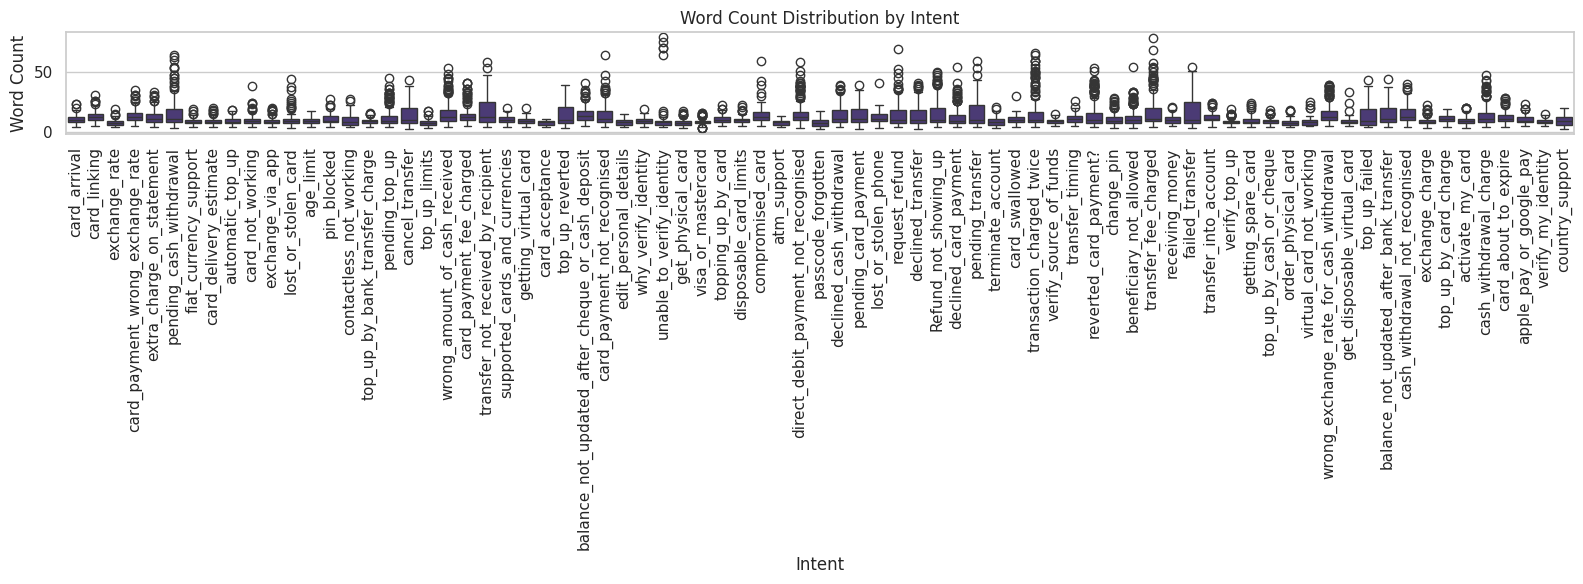

In [ ]:
plt.figure(figsize=(16, 6))

sns.boxplot(data=train,x='category',y='word_count')

plt.xticks(rotation=90)
plt.title("Word Count Distribution by Intent"),
plt.xlabel("Intent")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()

The box plot illustrates the distribution of word counts categorized by intent, revealing a high level of consistency across the majority of the 77 classes. Most intents show a ``very similar median and interquartile range``, suggesting that banking customers generally use a comparable amount of detail regardless of their specific request.

However, the visualization also highlights interesting variations and "busy" intents. While most categories stay within a compact range, certain intents exhibit a significantly ``higher number of outliers``. These scattered points above the boxes represent more descriptive or complex customer queries that deviate from the typical short-form style. This indicates that while the general language is concise, specific topics naturally prompt users to provide more background information or context.

This variance across intents is a key insight for the modeling phase. It shows that the model must be robust enough to recognize the same intent whether it is delivered as a three-word command or a much longer, detailed explanation.

Overall, the relative stability of the medians across so many categories suggests that ``word count alone is not a strong predictor`` of intent, reinforcing the need for a sophisticated semantic model like RoBERTa to capture the underlying meaning.

**What are the Most Frequent Bi-grams and Tri-grams in Customer Queries?**

In [ ]:
def get_top_n_grams(corpus, n=None, g=1):
    vec = CountVectorizer(ngram_range=(g, g), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

In [ ]:
top_bigrams = get_top_n_grams(train['text'], n=25, g=2)
top_bigrams

[('exchange rate', np.int64(293)),
 ('new card', np.int64(226)),
 ('card payment', np.int64(202)),
 ('virtual card', np.int64(181)),
 ('cash withdrawal', np.int64(165)),
 ('money account', np.int64(148)),
 ('transfer money', np.int64(118)),
 ('long does', np.int64(109)),
 ('direct debit', np.int64(102)),
 ('extra fee', np.int64(97)),
 ('use card', np.int64(95)),
 ('charged fee', np.int64(94)),
 ('charged extra', np.int64(90)),
 ('change pin', np.int64(86)),
 ('using card', np.int64(85)),
 ('disposable virtual', np.int64(85)),
 ('disposable cards', np.int64(82)),
 ('credit card', np.int64(77)),
 ('cash atm', np.int64(74)),
 ('add money', np.int64(73)),
 ('days ago', np.int64(69)),
 ('activate card', np.int64(59)),
 ('don know', np.int64(59)),
 ('didn make', np.int64(59)),
 ('verify identity', np.int64(59))]

The Bi-gram analysis highlights the dominant themes in the dataset, showing a heavy focus on transactional activities and card management. The high frequency of phrases like ``"exchange rate," "new card," and "virtual card"`` indicates that customers use very specific, standardized terminology when addressing their banking needs.

Beyond basic requests, the data reveals a clear concern regarding costs and timelines, as seen in pairs like ``"extra fee" and "long does."`` These recurring word clusters provide strong semantic signals that are essential for distinguishing between the 77 intent classes.

This consistency in language confirms that the dataset is rich in recognizable patterns. From a modeling perspective, the presence of such well-defined Bi-grams reinforces the need for a context-aware approach, as capturing these word associations is key to accurately predicting customer intent.

In [ ]:
top_trigrams = get_top_n_grams(train['text'], n=20, g=3)
top_trigrams

[('disposable virtual card', np.int64(63)),
 ('exchange rate wrong', np.int64(43)),
 ('transfer money account', np.int64(34)),
 ('charged extra fee', np.int64(33)),
 ('direct debit payment', np.int64(33)),
 ('exchange rate applied', np.int64(27)),
 ('wrong exchange rate', np.int64(26)),
 ('order new card', np.int64(24)),
 ('couple days ago', np.int64(24)),
 ('disposable virtual cards', np.int64(22)),
 ('card payment cancelled', np.int64(22)),
 ('extra fee statement', np.int64(21)),
 ('long does transfer', np.int64(21)),
 ('add money account', np.int64(20)),
 ('card payment declined', np.int64(20)),
 ('card payment reverted', np.int64(19)),
 ('cash withdrawal pending', np.int64(18)),
 ('link new card', np.int64(17)),
 ('exchange rate incorrect', np.int64(17)),
 ('activate new card', np.int64(16))]

The Tri-gram analysis provides a deeper layer of semantic clarity, revealing the specific contexts in which customers use banking terminology. While Bi-grams identify general topics, these three-word clusters highlight precise concerns, such as ``"exchange rate wrong," "extra fee statement," and "card payment declined."`` This level of detail is crucial for distinguishing between similar intents, as it captures the specific "pain point" of the user.

A significant portion of the Tri-grams focuses on transaction status and troubleshooting. Phrases like ``"cash withdrawal pending," "card payment reverted," and "long does transfer"`` show that customers are often seeking updates or resolutions for ongoing processes. Additionally, the prevalence of terms like ``"disposable virtual card" and "order new card"`` reinforces the importance of product-specific lifecycle management in the dataset.

From a modeling perspective, these Tri-grams confirm that word order and local context are highly informative. The existence of these stable, recurring patterns suggests that a model capable of understanding long-range dependencies will perform well.

Overall, this analysis validates the high signal-to-noise ratio in the text, as users rely on consistent, descriptive phrases to communicate complex banking issues.

**Which Keywords Overlap Across Multiple Intents and Cause Ambiguity?**

In [ ]:
vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(train['text'])
words = vec.get_feature_names_out()

word_df = pd.DataFrame(X.toarray(), columns=words)
word_df['category_label'] = train['category'].values

word_category_counts = {}

for word in words:
    unique_categories = word_df[word_df[word] > 0]['category_label'].nunique()
    word_category_counts[word] = unique_categories

overlap_df = pd.DataFrame(list(word_category_counts.items()), columns=['Word', 'Category_Count'])
overlap_df = overlap_df.sort_values(by='Category_Count', ascending=False)

overlap_df.head(20)

,Word,Category_Count
1164,need,72
1808,tell,66
996,know,63
39,account,62
853,help,60
275,card,59
1020,like,57
561,don,57
555,does,56
1077,make,54


This analysis shows that many common words are shared across dozens of different categories, which creates a significant challenge for understanding user intent. For example, a core term like ``"card"`` appears in ``59 different classes``, and ``"account"`` is spread across ``53``. Because these words are so common, seeing them in a sentence doesn't immediately tell us what the user actually wants.

Other frequent words like ``"need," "tell," and "help"`` also show up almost everywhere. While these words are used very often, they don't help much in distinguishing one intent from another since they are part of nearly all types of banking queries. Even more specific terms like ``"money" or "app"`` are found in about 50 different categories, leading to a lot of overlap.

The main takeaway here is that individual keywords are often ambiguous. To understand the user's true goal, we cannot rely on single words alone. Instead, we must look at how these words are used together in a full sentence to clear up the confusion caused by these overlapping terms.

**What are the Primary Signature Words and Their Frequencies for All 77 Intents?**

In [ ]:
def get_intent_word_counts(df, top_n=2):
    intent_groups = df.groupby('category')['text'].apply(lambda x: ' '.join(x)).reset_index()

    results = []

    for _, row in intent_groups.iterrows():
        cat_name = row['category']
        text = [row['text']]

        vec = CountVectorizer(stop_words='english').fit(text)
        bag_of_words = vec.transform(text)

        sum_words = bag_of_words.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]

        formatted_words = [f"{w} ({c})" for w, c in words_freq]
        results.append([cat_name] + formatted_words)

    columns = ['Category'] + [f'Top_Word_{i+1}' for i in range(top_n)]
    final_df = pd.DataFrame(results, columns=columns)
    return final_df

intent_signatures = get_intent_word_counts(train, top_n=2)
pd.set_option('display.max_rows', 77)
intent_signatures

,Category,Top_Word_1,Top_Word_2
0,Refund_not_showing_up,refund (167),statement (42)
1,activate_my_card,card (153),activate (94)
2,age_limit,account (72),open (37)
3,apple_pay_or_google_pay,pay (92),apple (69)
4,atm_support,card (39),atm (35)
5,automatic_top_up,auto (74),automatically (33)
6,balance_not_updated_after_bank_transfer,transfer (119),account (72)
7,balance_not_updated_after_cheque_or_cash_deposit,account (90),cash (82)
8,beneficiary_not_allowed,transfer (101),beneficiary (65)
9,cancel_transfer,cancel (82),transaction (75)


While many common words are shared across the dataset, this analysis identifies the "signature words" that define each of the 77 intents. By extracting the most frequent words for every category, we can see a clear and logical mapping between the user's language and the target labels. For example, in the ``"activate_my_card"`` category, the word ``"activate"`` stands out, while in ``"card_payment_wrong_exchange_rate"`` terms like ``"exchange" and "rate"`` become the primary signals.

These signature words act as the strongest indicators for the classification task. Even when a query contains common or ambiguous terms, the presence of these specific keywords—such as "``refund"`` for refund-related issues or ``"pin"`` for security tasks—helps steer the model toward the correct intent. The high frequency of these relevant terms across all categories shows that the dataset is well-structured and contains reliable patterns for each class.

Overall, this mapping confirms that despite the overlaps in general banking vocabulary, every intent has a distinct ``"linguistic fingerprint"``. This balance between shared language and unique signature words is exactly what makes the dataset both challenging and ideal for training a robust intent recognition model.

**How Do Special Characters and Symbols Influence Intent Identification?**

In [ ]:
train_copy = train.copy()
train_copy['has_question_mark'] = train_copy['text'].str.contains('\?').astype(int)
train_copy['has_currency'] = train_copy['text'].str.contains('[\$\£\€]').astype(int)

question_dist = train_copy.groupby('category')['has_question_mark'].mean().sort_values(ascending=False)

print("Intent Classes with Highest Question Mark Usage:")
display(question_dist.head(10))

currency_dist = train_copy.groupby('category')['has_currency'].mean().sort_values(ascending=False)
print("\nIntent Classes with Highest Currency Symbol Usage:")
display(currency_dist.head(5))

Intent Classes with Highest Question Mark Usage:


,has_question_mark
category,
top_up_by_bank_transfer_charge,0.936937
card_acceptance,0.932203
exchange_charge,0.925620
transfer_timing,0.921875
receiving_money,0.915789
age_limit,0.900000
atm_support,0.896552
automatic_top_up,0.889764
top_up_by_card_charge,0.885965



Intent Classes with Highest Currency Symbol Usage:


,has_currency
category,
extra_charge_on_statement,0.469880
wrong_amount_of_cash_received,0.133333
cash_withdrawal_not_recognised,0.056250
failed_transfer,0.007299
balance_not_updated_after_cheque_or_cash_deposit,0.005525


The analysis of special characters reveals that punctuation and symbols are not just noise, but actually carry strong intent signals. A striking observation is the use of ``question marks``, which appear in ``over 90%`` of samples for classes like ``"top_up_by_bank_transfer_charge" and "card_acceptance"``. This suggests that certain intents are almost exclusively expressed as direct inquiries, making the question mark a key indicator for these categories.

``Currency symbols`` also provide a unique "fingerprint" for specific financial queries. For example, ``nearly 47%`` of requests in the ``"extra_charge_on_statement"`` category contain symbols like *$, £, or €*. While these symbols are rare in the overall dataset, their high density in specific classes makes them highly discriminative features for identifying transaction-related issues.

Overall, these findings show that special characters provide valuable context that distinguishes between asking a question and making a statement. This insight is crucial for the upcoming preprocessing phase, as it suggests that keeping or specifically marking these symbols—rather than blindly removing all punctuation—could help the model better recognize the user's tone and intent.

**What are the Dominant Terms in the Top 6 Intent Categories?**

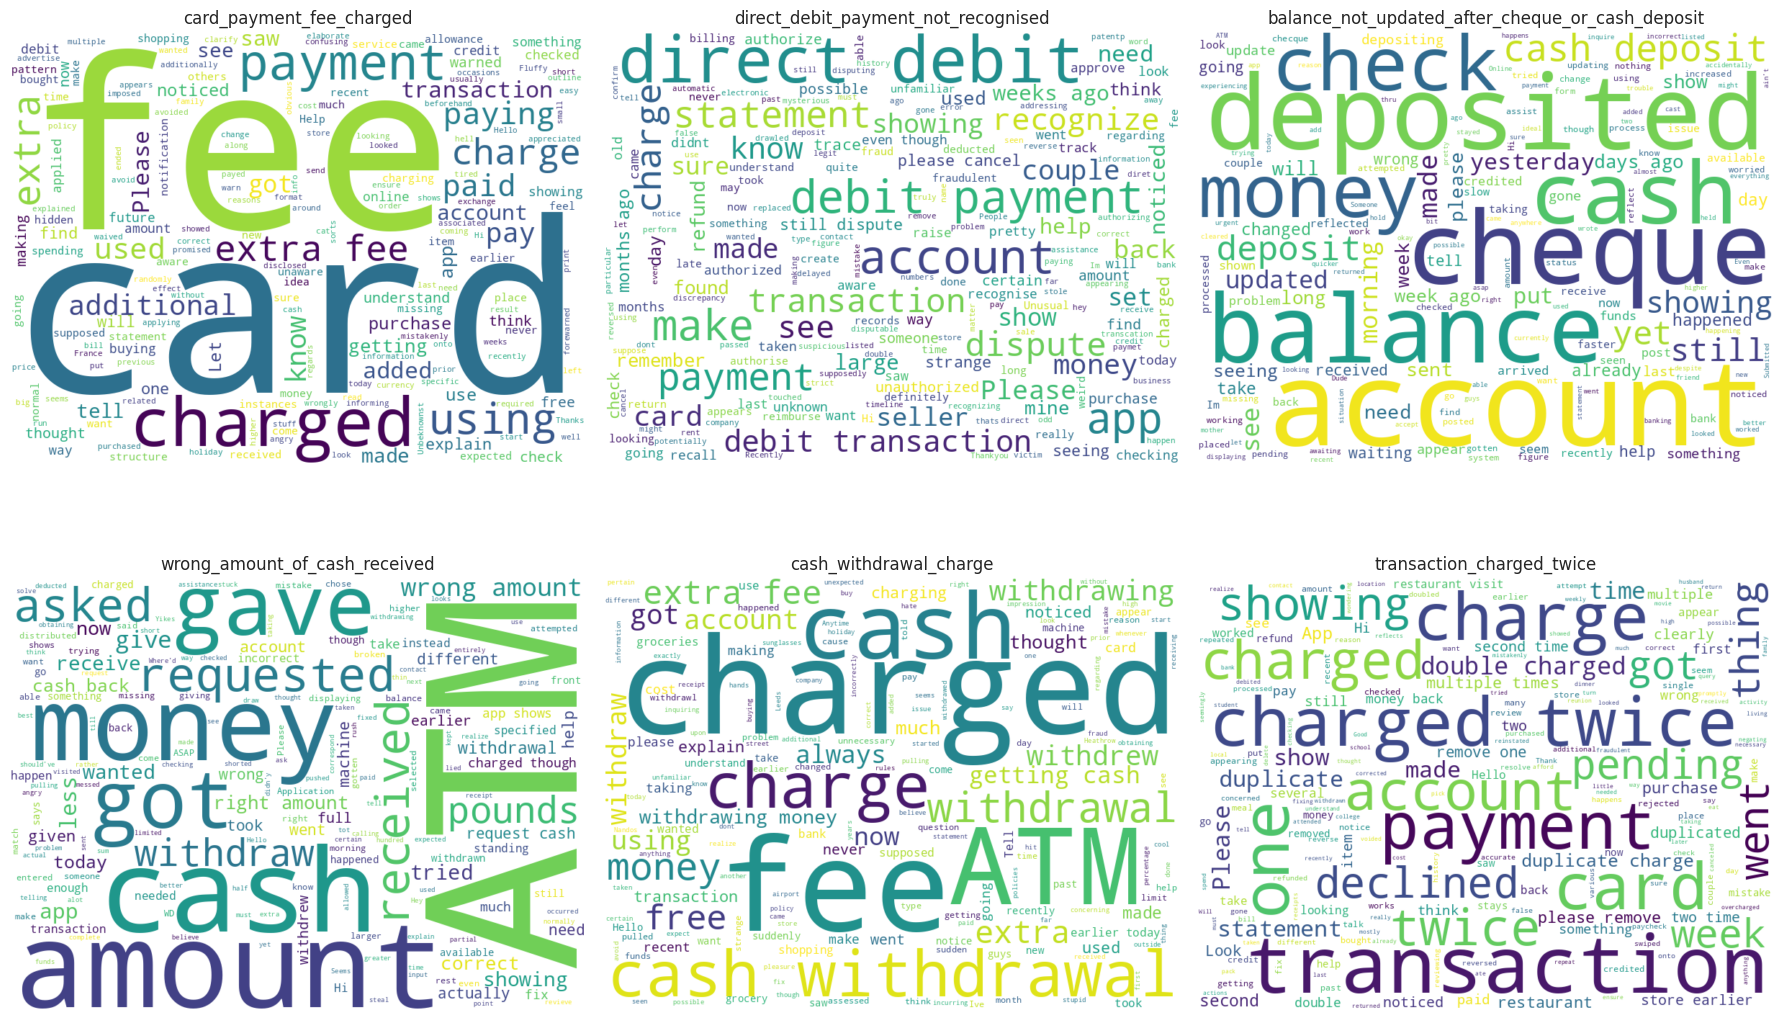

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
top_intents = train['category'].value_counts().head(6).index

for idx, intent in enumerate(top_intents):
    ax = axes[idx // 3, idx % 3]
    text = ' '.join(train[train['category'] == intent]['text'])

    # Generate word clouds
    wordcloud = WordCloud(width=800, height=600,
                         background_color='white').generate(text)

    ax.imshow(np.array(wordcloud.to_image()), interpolation='bilinear')
    ax.set_title(intent, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

The Wordcloud visualization provides a clear, thematic breakdown of the most frequent intents, confirming that each category has its own distinct vocabulary. For instance, in the ``"card_payment_fee_charged"`` category, terms like ``"fee", "charged", and "card"`` dominate the space, while ``"ATM", "cash", and "amount``" define the ``"wrong_amount_of_cash_received"`` class. These visual clusters show that users rely on a specific set of "action words" to describe their problems.

The clarity of these wordclouds suggests that the dataset contains very strong, localized signals for each intent. In categories like ``"direct_debit_payment_not_recognised"``, the prominence of words such as ``"direct", "debit" and "transaction"`` shows that there is little ambiguity within the top categories. This thematic consistency is a positive indicator, as it means the data is naturally well-separated based on the actual words users choose.

Overall, this analysis reinforces the idea that customer queries are highly descriptive and goal-oriented. By visualizing the most dominant terms, we can see that even though the banking domain has a shared general vocabulary, the specific combination of words remains unique to each intent. This high level of semantic focus is ideal for training a system to accurately categorize diverse user requests.

---

## Personally Identifiable Information (PII)

Before we proceed with building and training our models to assist real-world banking customers, we must ensure that all personal data is handled responsibly. In this project, we are adopting a ``"Privacy-First"`` approach by applying PII (Personally Identifiable Information) protection prior to the training phase.

Instead of applying redaction only during production deployment, we will clean both our training and test datasets at the very beginning. This ensures that our model never encounters sensitive information during its learning process, preventing data leakage and ensuring it learns to recognize redacted labels as part of its natural context.

**Why We Are Redacting Data Before Modeling:**

- **Model Consistency:** By training the model on the same format it will encounter in production (e.g., ``[REDACTED]``), we will improve the accuracy of intent classification.

- **Security by Design:** We aim to ensure that our datasets are free from real emails, SSNs, or card numbers from the very start of the development lifecycle.

**PII Protection Strategy:**

We will apply two distinct approaches to protect sensitive information:

1. Hashing (SHA-256) for Customer Identification:

    - This will be used for information that helps track a customer's journey without revealing their identity, such as email addresses and phone numbers.

    - Example: ``firstname.lastname@email.com`` → ``[HASH:55f537baf75630a8]``

2. Complete Redaction for Critical & Financial Information:

    - Critical Details: SSNs, home addresses, driver’s licenses, and passport numbers will be fully masked.

    - Financial Credentials: Credit card numbers, CVV codes, PINs, and account/routing numbers will be replaced with specific redaction labels to prevent any exposure.

    - Example: ``1234-5678-9012-3456`` → ``[CARD NUMBER REDACTED]``

By implementing this strategy at the preprocessing stage, we are ensuring that our entire machine learning pipeline—from training to inference—is fully compliant with data privacy best practices.

In [ ]:
def remove_pii(text, hash_identifiers=False):
    """
    Remove or hash PII from customer queries.
    """
    # Identify PII
    EMAIL_PATTERN = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
    PHONE_PATTERN = r'\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b'
    SSN_PATTERN = r'\b\d{3}-\d{2}-\d{4}\b'
    CREDIT_CARD_PATTERN = r'\b\d{4}[\s-]?\d{4}[\s-]?\d{4}[\s-]?\d{4}\b'
    ACCOUNT_PATTERN = r'\b[A-Z]{2}\d{2}[A-Z0-9]{1,30}\b'
    ROUTING_NUMBER_PATTERN = r'\b\d{9}\b'
    ZIP_CODE_PATTERN = r'\b(?:ZIP|postal|code)\s*[:#-]?\s*\d{5}(?:-\d{4})?\b'
    DATE_OF_BIRTH_PATTERN = r'\b(?:\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2})\b'
    NAME_PATTERN = r'\b(?:Mr\.|Mrs\.|Ms\.|Dr\.)\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)+\b'
    DRIVERS_LICENSE_PATTERN = r'\b[A-Z]\d{7,8}\b|\b[A-Z]{1,2}\d{5,7}\b'
    IP_ADDRESS_PATTERN = r'\b(?:\d{1,3}\.){3}\d{1,3}\b'
    ADDRESS_PATTERN = r'\b\d{2,}\s+[A-Za-z]+(?:\s+[A-Za-z]+)*\s+(?:Street|St|Avenue|Ave|Road|Rd|Boulevard|Blvd|Lane|Ln|Drive|Dr|Court|Ct|Way)\b'
    CVV_PATTERN = r'\b(?:CVV|CVC)[\s:is]*\d{3,4}\b'
    PIN_PATTERN = r'\b(?:PIN)[\s:is]*\d{4,6}\b'
    PASSPORT_PATTERN = r'\b[A-Z]\d{8}\b|\b[A-Z]{2}\d{7}\b'

    if pd.isna(text):
        return text

    # Hashing function
    def hash_value(match):
        value = match.group(0)
        hashed = hashlib.sha256(value.encode()).hexdigest()[:16]
        return f"[HASH:{hashed}]"

    # Handle email and phone with hashing
    if hash_identifiers:
        text = re.sub(EMAIL_PATTERN, hash_value, text, flags=re.IGNORECASE)
        text = re.sub(PHONE_PATTERN, hash_value, text)
    else:
        text = re.sub(EMAIL_PATTERN, '[EMAIL REDACTED]', text, flags=re.IGNORECASE)
        text = re.sub(PHONE_PATTERN, '[PHONE NUMBER REDACTED]', text)

    # Redact all other PII
    text = re.sub(SSN_PATTERN, '[SSN REDACTED]', text)
    text = re.sub(CREDIT_CARD_PATTERN, '[CARD NUMBER REDACTED]', text)
    text = re.sub(ACCOUNT_PATTERN, '[ACCOUNT NUMBER REDACTED]', text)
    text = re.sub(ROUTING_NUMBER_PATTERN, '[ROUTING/ACCOUNT NUMBER REDACTED]', text)
    text = re.sub(CVV_PATTERN, '[CVV NUMBER REDACTED]', text, flags=re.IGNORECASE)
    text = re.sub(PIN_PATTERN, '[PIN NUMBER REDACTED]', text, flags=re.IGNORECASE)
    text = re.sub(PASSPORT_PATTERN, '[PASSPORT NUMBER REDACTED]', text)
    text = re.sub(DRIVERS_LICENSE_PATTERN, '[LICENSE NUMBER REDACTED]', text)
    text = re.sub(DATE_OF_BIRTH_PATTERN, '[DOB REDACTED]', text)
    text = re.sub(ADDRESS_PATTERN, '[ADDRESS REDACTED]', text, flags=re.IGNORECASE)
    text = re.sub(NAME_PATTERN, '[NAME REDACTED]', text)
    text = re.sub(ZIP_CODE_PATTERN, '[ZIP REDACTED]', text)
    text = re.sub(IP_ADDRESS_PATTERN, '[IP REDACTED]', text)

    return text

Let's first apply our PII protection strategy without hashing to a few test cases:

In [ ]:
print("=== Standard PII Redaction ===")

test_cases = [
    "My routing number is 021000021 and account is 123456789",
    "I was born on 03/15/1985 and live at 123 Main Street, ZIP 02139",
    "My card CVV is 123 and PIN is 4567",
    "Contact Mr. John Smith at his office",
    "My driver's license is D1234567",
    "My passport number is AB1234567",
    "Login from IP 192.168.1.1 failed"
]

for test_case in test_cases:
    print(f"Original: {test_case}")
    print(f"Redacted: {remove_pii(test_case)}")
    print("-" * 30)

=== Standard PII Redaction ===
Original: My routing number is 021000021 and account is 123456789
Redacted: My routing number is [ROUTING/ACCOUNT NUMBER REDACTED] and account is [ROUTING/ACCOUNT NUMBER REDACTED]
------------------------------
Original: I was born on 03/15/1985 and live at 123 Main Street, ZIP 02139
Redacted: I was born on [DOB REDACTED] and live at [ADDRESS REDACTED], [ZIP REDACTED]
------------------------------
Original: My card CVV is 123 and PIN is 4567
Redacted: My card [CVV NUMBER REDACTED] and [PIN NUMBER REDACTED]
------------------------------
Original: Contact Mr. John Smith at his office
Redacted: Contact [NAME REDACTED] at his office
------------------------------
Original: My driver's license is D1234567
Redacted: My driver's license is [LICENSE NUMBER REDACTED]
------------------------------
Original: My passport number is AB1234567
Redacted: My passport number is [ACCOUNT NUMBER REDACTED]
------------------------------
Original: Login from IP 192.168.1.1 

Let's now apply our PII protection strategy with hashing:

In [ ]:
print("\n=== With Identifier Hashing (for customer tracking) ===")
test_with_contact = "Email me at john.doe@email.com or call 123-456-7890"
print(f"Original: {test_with_contact}")
print(f"Redacted: {remove_pii(test_with_contact, hash_identifiers=False)}")
print(f"Hashed:   {remove_pii(test_with_contact, hash_identifiers=True)}")
print()


=== With Identifier Hashing (for customer tracking) ===
Original: Email me at john.doe@email.com or call 123-456-7890
Redacted: Email me at [EMAIL REDACTED] or call [PHONE NUMBER REDACTED]
Hashed:   Email me at [HASH:55f537baf75630a8] or call [HASH:29ec0a06044bedff]



Finally, let's apply the PII protection to our train and test sets before we move on to modeling.

In [ ]:
train['text'] = train['text'].apply(remove_pii)
test['text'] = test['text'].apply(remove_pii)

---

## Baseline Multi-Layer Perceptron (MLP)

Before implementing advanced Transformer-based architectures, we will develop a ``Multi-Layer Perceptron (MLP)`` to serve as our ``baseline text classifier``. This initial step will allow us to set a clear benchmark for the 77-intent classification task using a simpler, non-contextual approach.

The primary objectives for this baseline model will be:

- **Benchmarking:** It will create a performance floor to help us quantify exactly how much ``"contextual advantage"`` a model like RoBERTa provides.

- **Contextual Gap Analysis:** By treating text as a ``"bag of words"``, the MLP will reveal which intents are identifiable by keywords alone and which ones require an understanding of word order.

**Preprocessing: Encoding Class Labels**

To prepare the dataset for training, we will use a ``LabelEncoder`` to map each text-based intent to a unique numerical value.

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(train["category"].astype(str).values)
y_test  = le.transform(test["category"].astype(str).values)

num_classes = len(le.classes_)
print(f"Num Classes: {num_classes}")

Num Classes: 77


**Move to GPU**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**Calculating Class Weights for Imbalanced Data**

To handle class imbalance, we will calculate ``class weights`` so the model treats rare and frequent intents with equal importance.

In [ ]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

**Preprocessing: Text Vectorization with TF-IDF**

To represent our text numerically, we will use ``TF-IDF Vectorization`` with an ``n-gram range of 1 to 3``, allowing the model to capture both individual words and meaningful phrases. By limiting the vocabulary to the top ``50,000 features`` and ``removing common stop words``, we will ensure that the MLP focuses on the most informative terms while maintaining a consistent input structure across both training and test sets.

In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    max_features=50_000,
    strip_accents="unicode",
    stop_words="english"
)

X_train = tfidf.fit_transform(train["text"].astype(str).values)
X_test  = tfidf.transform(test["text"].astype(str).values)

input_size = X_train.shape[1]
print(f"Input Size: {input_size}")

Input Size: 8690


**Preprocessing: Creating TF-IDF Dataset**

To make the TF-IDF features compatible with PyTorch, we will define a custom ``Dataset`` class that converts sparse matrices into dense tensors. This class will handle the input-label pairs and ensure that the data is efficiently fed into the model during training and evaluation.

In [ ]:
class TfidfDataset(Dataset):
    def __init__(self, X_sparse, y):
      self.X = X_sparse
      self.y = y

    def __len__(self):
      return self.X.shape[0]

    def __getitem__(self, idx):
      x = self.X[idx].toarray().astype(np.float32).flatten()
      y = np.int64(self.y[idx])
      return torch.from_numpy(x), torch.tensor(y)

train_ds = TfidfDataset(X_train, y_train)
test_ds  = TfidfDataset(X_test, y_test)

**Preprocessing: Creating DataLoaders**

Finally, we will wrap the datasets into PyTorch ``DataLoaders`` to handle batching and shuffling, ensuring efficient data flow during the training and evaluation phases.

In [ ]:
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False)

**Baseline Model Architecture**

Our baseline model consists of a Multi-Layer Perceptron (MLP) structured to map TF-IDF features directly to the 77 intent classes. The design focuses on a balance between learning capacity and stability.

The network architecture includes:

- **Three Dense Layers:** A layered structure that reduces complex input data into final intent predictions.

- **ReLU Activation:** Applied between layers to help the model learn non-linear patterns in the text.

- **Dropout (0.2):** Integrated after each hidden layer to prevent overfitting and ensure the model generalizes well to new data.

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size: int, hidden_size=512, output_size=77):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

**Instantiate MLP, Loss Function, and Optimizer**

To prepare for training, we will initialize the SimpleMLP and define our optimization strategy:

- **Weighted Loss:** We'll use ``Cross-Entropy Loss`` with class weights to support learning across all intents.

- **AdamW Optimizer:** We'll use the ``AdamW optimizer`` to manage parameter updates with a learning rate of $1e-3$.

In [ ]:
model = SimpleMLP(input_size=input_size, hidden_size=512, output_size=num_classes).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

**Baseline Model Training**

Next, we will implement a training function to optimize the MLP over 10 epochs. This process ensures the model learns to map text features to intents through a standard training loop:

- **Training Loop:** We will iterate through the data in batches, performing forward and backward passes to update the model weights.

- **Optimization:** We will use the AdamW optimizer to minimize the Cross-Entropy Loss at each step.

- **Performance Tracking:** We will monitor the average loss and accuracy for each epoch to track the model's progress.

In [ ]:
def train_model(model, train_loader, loss_fn, optimizer, num_epochs=5, device=None):
    if device is None:
        device = next(model.parameters()).device

    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        correct = 0
        total = 0
        num_batches = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            # Forward Pass
            logits = model(batch_X)
            loss = loss_fn(logits, batch_y)

            # Backward Pass
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            # Training predictions
            epoch_loss += loss.item()
            num_batches += 1
            preds = logits.argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

        avg_loss = epoch_loss / num_batches
        accuracy = correct / total

        print(f"Epoch [{epoch + 1}/{num_epochs}] | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

# Train Model
train_model(
    model=model,
    train_loader=train_loader,
    loss_fn=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device=device
)

Epoch [1/10] | Loss: 3.9531 | Accuracy: 0.2217
Epoch [2/10] | Loss: 1.2365 | Accuracy: 0.7357
Epoch [3/10] | Loss: 0.4740 | Accuracy: 0.8855
Epoch [4/10] | Loss: 0.3033 | Accuracy: 0.9247
Epoch [5/10] | Loss: 0.2238 | Accuracy: 0.9414
Epoch [6/10] | Loss: 0.1767 | Accuracy: 0.9534
Epoch [7/10] | Loss: 0.1533 | Accuracy: 0.9584
Epoch [8/10] | Loss: 0.1341 | Accuracy: 0.9629
Epoch [9/10] | Loss: 0.1216 | Accuracy: 0.9660
Epoch [10/10] | Loss: 0.1110 | Accuracy: 0.9661


The training process demonstrates a highly efficient learning curve, with the model rapidly adapting to the intent classification task. We observed a significant performance leap in the very early stages, where accuracy jumped from ``22.17% to 73.57%`` by the second epoch, proving that the TF-IDF features provide a strong signal for the MLP to distinguish between banking queries.

As training progressed, the ``AdamW`` optimizer maintained a smooth and stable trajectory, successfully reducing the loss from ``3.9531 to a final 0.1110``. This consistent decline, paired with a final training accuracy of ``96.61%``, indicates that our architectural choices—specifically the hidden layer depth and dropout regularization—effectively captured the complex patterns across all 77 intent classes without signs of instability.

**Generate Testing Set Predictions**

We will define a prediction function to generate labels for the test set, using evaluation mode to ensure an efficient and accurate comparison against the actual results.

In [ ]:
def predict(model, dataloader, device):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)
            preds = logits.argmax(dim=1)

            all_predictions.append(preds.cpu().numpy())
            all_labels.append(batch_y.cpu().numpy())

    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_labels)
    return y_pred, y_true

# Generate test predictions
mlp_y_pred, mlp_y_true = predict(model=model, dataloader=test_loader, device=device)

**Evaluating the Baseline Model**

In [ ]:
mlp_accuracy = accuracy_score(mlp_y_true, mlp_y_pred)
print(f"Overall Accuracy Score: {mlp_accuracy:.4f}")

print(classification_report(mlp_y_true, mlp_y_pred, target_names=le.classes_))

Overall Accuracy Score: 0.8276
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.79      0.93      0.85        40
                                activate_my_card       0.91      0.97      0.94        40
                                       age_limit       1.00      0.97      0.99        40
                         apple_pay_or_google_pay       1.00      0.97      0.99        40
                                     atm_support       0.82      0.90      0.86        40
                                automatic_top_up       1.00      0.93      0.96        40
         balance_not_updated_after_bank_transfer       0.68      0.68      0.68        40
balance_not_updated_after_cheque_or_cash_deposit       0.80      0.88      0.83        40
                         beneficiary_not_allowed       0.90      0.88      0.89        40
                                 cancel_transfer       1.00      0.9

Upon evaluating the model on the unseen testing dataset, we achieved an ``overall accuracy of 82.76%``. While this is a strong result for a 77-class classification task, the performance gap compared to the training set suggests a degree of overfitting and highlights the inherent complexity of banking queries. We observed that the MLP performs exceptionally well on distinct categories such as ``passcode_forgotten (1.00 F1-score)`` and ``age_limit (0.99 F1-score)``, where specific keywords likely provide clear signals.

However, the model struggles with categories that share high semantic similarity. For instance, ``topping_up_by_card (0.53 F1-score)`` and ``verify_my_identity (0.58 F1-score)`` show significantly lower performance, often being confused with related intents like card charges or identity verification reasons. These results indicate that while our TF-IDF features capture general patterns, they may lack the deep contextual nuance required to distinguish between subtle variations in customer requests. This performance serves as a solid baseline, but it also points toward the need for more advanced linguistic features or further regularization to improve generalization.

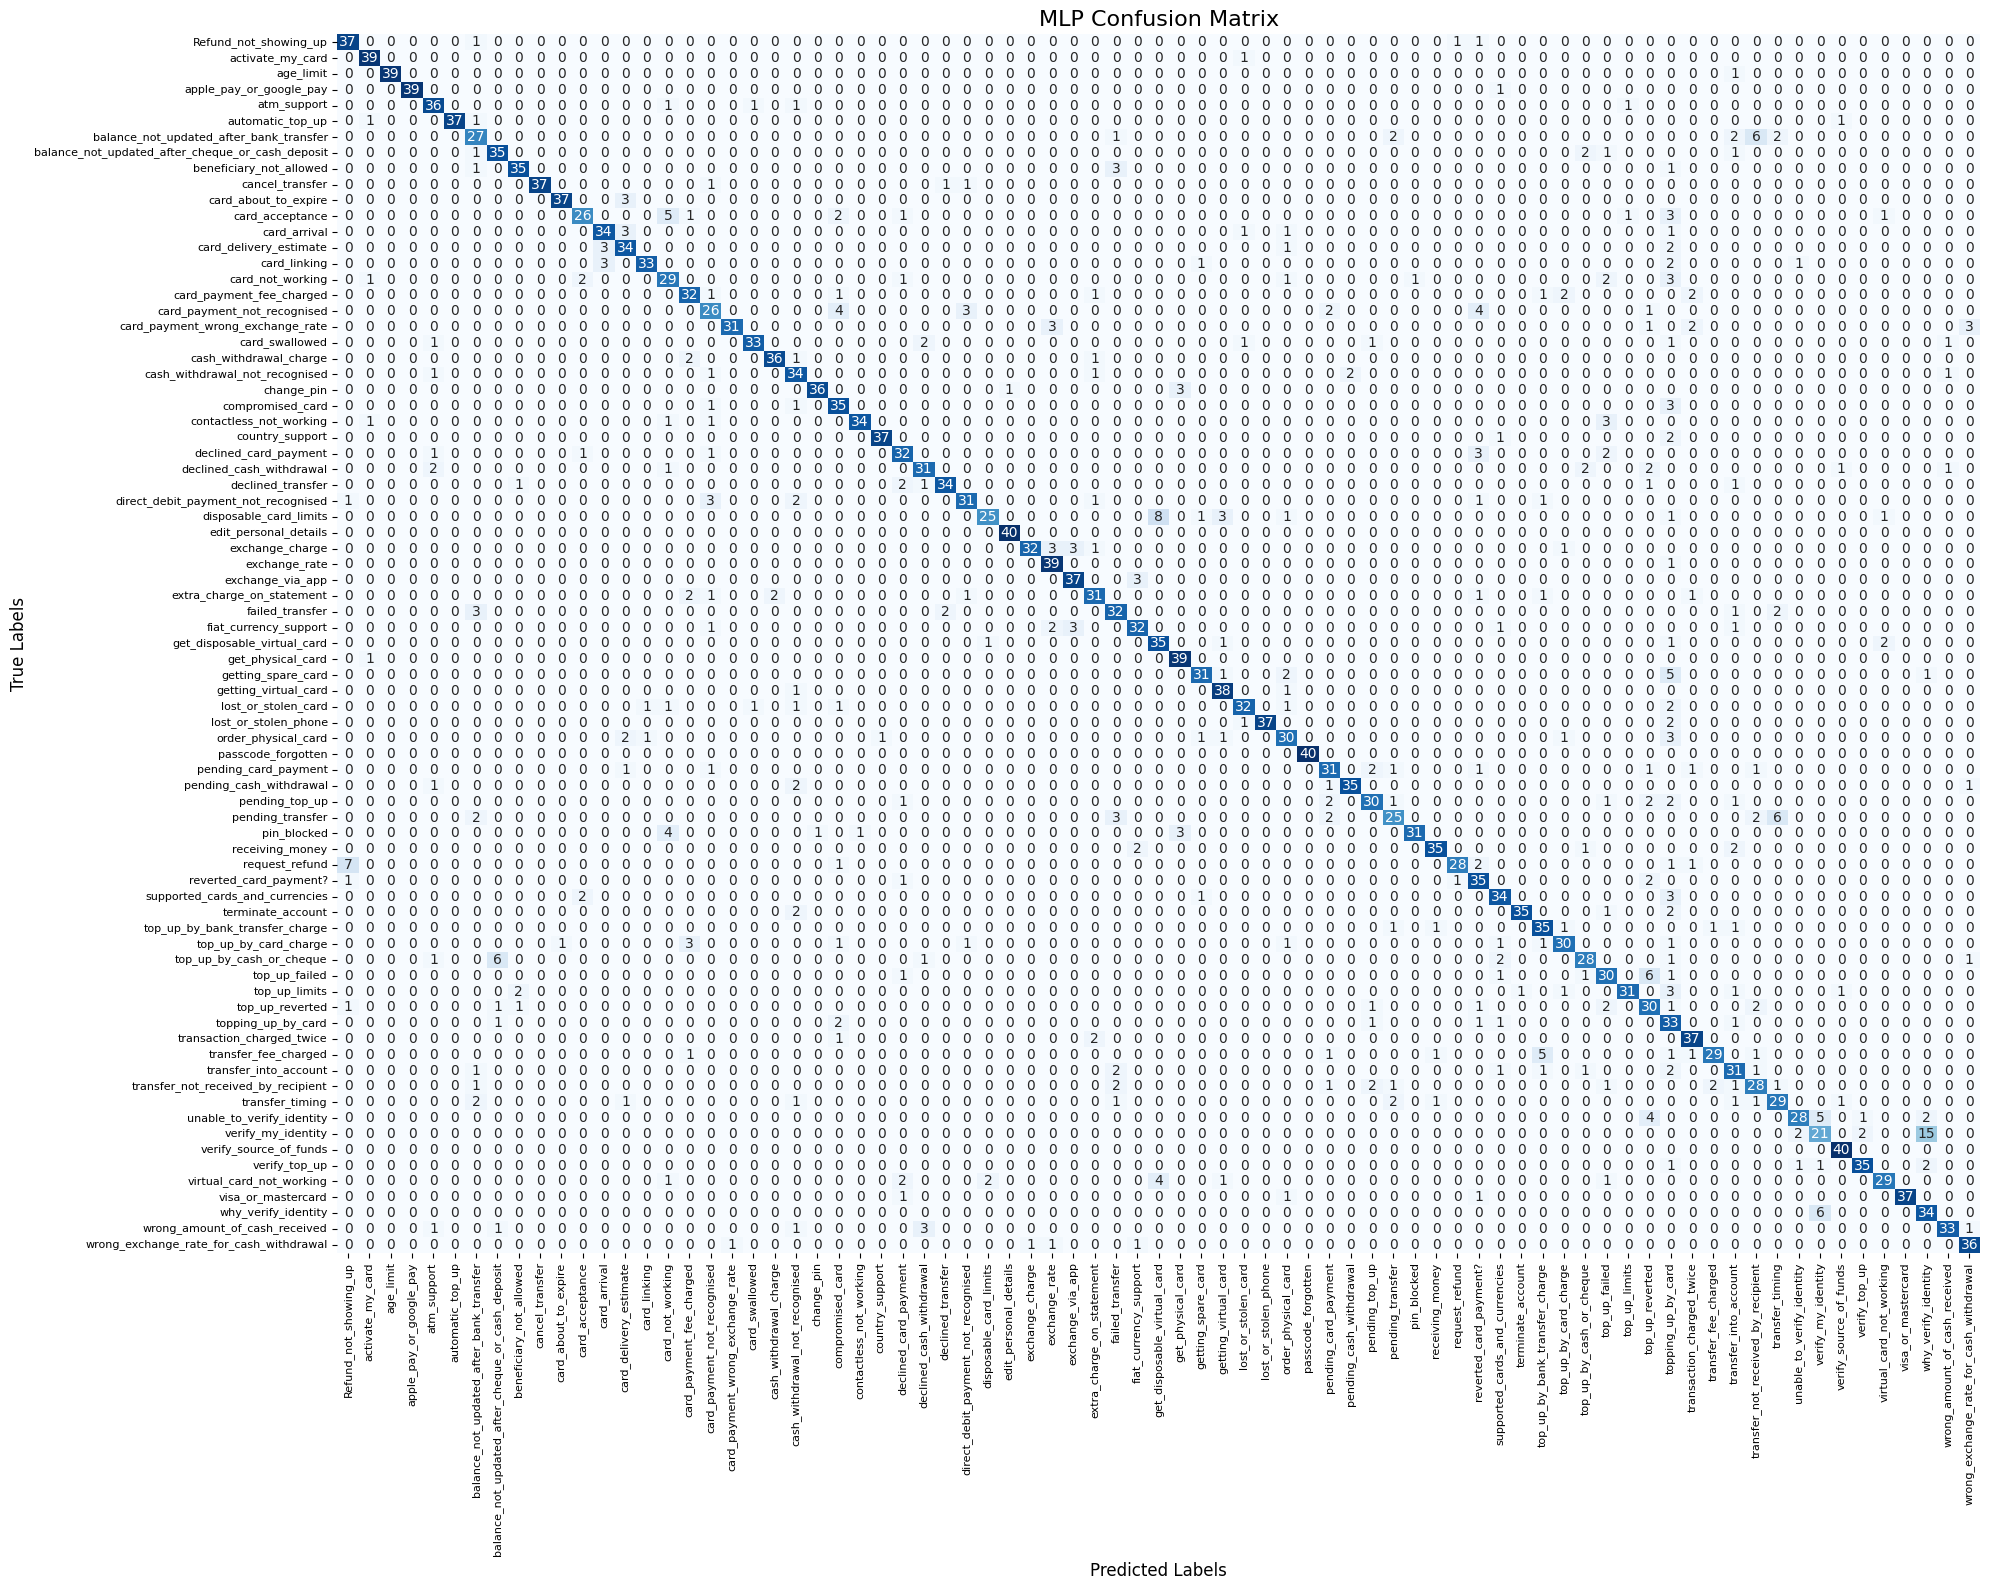

In [ ]:
cm = confusion_matrix(mlp_y_true, mlp_y_pred)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=le.classes_, yticklabels=le.classes_)

plt.title('MLP Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

The confusion matrix reveals a strong diagonal dominance, proving the MLP successfully identifies most of the 77 intent classes. However, the "noise" outside the diagonal highlights clear clusters of confusion between semantically similar categories, such as different types of ``card issues and transfer statuses``. This suggests that while TF-IDF captures key terms effectively, the model occasionally struggles to distinguish between queries with ``high lexical overlap``.

---

## Finetune RoBERTa with LoRA

To improve upon our baseline, we will fine-tune a pre-trained ``RoBERTa`` model using ``LoRA (Low-Rank Adaptation)``. While our MLP performed well, RoBERTa’s contextual embeddings will allow us to better capture the subtle semantic differences between intent classes that a standard TF-IDF approach might miss.

By implementing LoRA, we will significantly reduce the computational cost of fine-tuning while maintaining high performance. Although we expect this process to be slower than training the MLP, we anticipate that LoRA-RoBERTa will deliver superior classification accuracy by understanding the deeper context of each banking query.

**Preprocessing: Encoding Class Labels**

Consistent with our previous approach, we will convert the categorical intent labels into integer-encoded values using a ``LabelEncoder``. We will map each unique intent category to a specific integer ID and fit the encoder on the training data before applying it to the test set to ensure consistency across all 77 classes. By maintaining a dedicated encoder for this stage, we will keep our RoBERTa labels independent and clearly defined for the fine-tuning process.



In [ ]:
train_hf = Dataset.from_pandas(train[["text", "category"]])
test_hf = Dataset.from_pandas(test[["text", "category"]])

train_hf = train_hf.map(lambda x: {"labels": le.transform([str(x["category"])])[0]})
test_hf = test_hf.map(lambda x: {"labels": le.transform([str(x["category"])])[0]})

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

**Preprocessing: Tokenization and Batch Padding**

Using the ``roberta-base tokenizer``, we will convert our raw text queries into subword-based tokens to make them compatible with the transformer architecture. We will set a maximum sequence length of ``256 tokens``, applying truncation to ensure that any longer queries are capped to maintain consistent input dimensions. To optimize efficiency during training, we will implement a ``DataCollatorWithPadding``, which dynamically pads sequences based on the longest example within each specific batch, rather than padding every sequence to the absolute maximum length.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

tokenized_train = train_hf.map(tokenize_function, batched=True)
tokenized_test = test_hf.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

**Set Up Finetuning Configuration**

To manage the fine-tuning process, we will use the ``TrainingArguments`` module to set our training and evaluation rules. We will define a specific learning rate and set the number of training epochs to give the model enough time to learn the banking intents. We will also adjust the batch sizes to make sure the training is both fast and memory-efficient. To ensure we keep the best version of our model, we will evaluate performance at the end of each epoch and load the best weights. Finally, we will use a fixed random seed so our results stay consistent and enable per-epoch logging to track the model's performance step by step.

In [ ]:
training_args = TrainingArguments(
    output_dir="./roberta-intent-results",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    push_to_hub=False,
    report_to="none",
    seed=42
)

**Configure LoRA for Parameter-Efficient Finetuning**

Next, we will apply ``LoRA`` to ``fine-tune RoBERTa`` efficiently using the ``PEFT`` library. We will load the roberta-base model and configure it for sequence classification across our 77 classes. By setting the rank to ``r=32`` and the ``scaling factor to 64``, we will target the ``query, key, and value`` projections within the model's attention layers. This approach allows us to train only a tiny fraction of the total parameters, significantly reducing the memory needed while still capturing the complex patterns in our banking dataset.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("roberta-base",num_labels=num_classes)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query","key","value"]
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
model.to(device)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,534,541 || all params: 126,239,386 || trainable%: 1.2156


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): RobertaForSequenceClassification(
      (roberta): RobertaModel(
        (embeddings): RobertaEmbeddings(
          (word_embeddings): Embedding(50265, 768, padding_idx=1)
          (token_type_embeddings): Embedding(1, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (position_embeddings): Embedding(514, 768, padding_idx=1)
        )
        (encoder): RobertaEncoder(
          (layer): ModuleList(
            (0-11): 12 x RobertaLayer(
              (attention): RobertaAttention(
                (self): RobertaSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleD

**Handling Class Imbalance with a Custom Trainer**

Since our dataset contains 77 different intents with varying numbers of examples, we will implement a custom ``WeightedLossTrainer`` to prevent the model from favoring majority classes. By ``overriding the compute_loss`` function and applying our pre-calculated class weights to the cross-entropy loss, we will ensure that underrepresented categories carry more weight during training. This approach enables RoBERTa to learn the unique characteristics of every single intent equally, leading to a more balanced and reliable performance across the entire banking dataset.

In [ ]:
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

**Finetuning the LoRA-RoBERTa Model**

Now, we will combine everything we have prepared into our ``WeightedLossTrainer``. By using our model, training settings, and tokenized datasets all together, we will start the fine-tuning process. This step also includes using the DataCollator to handle our data in efficient batches. Once the training is finished, we will evaluate the results to see how much RoBERTa has improved at recognizing the 77 intent classes compared to our first model.

In [ ]:
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
)

trainer.train()
eval_metrics = trainer.evaluate()
print(eval_metrics)

Epoch,Training Loss,Validation Loss
1,0.734902,0.506556
2,0.412523,0.339355
3,0.337988,0.293074
4,0.258522,0.264437
5,0.244472,0.261165


{'eval_loss': 0.26116523146629333, 'eval_runtime': 43.5158, 'eval_samples_per_second': 70.779, 'eval_steps_per_second': 4.435, 'epoch': 5.0}


The training of the ``LoRA-RoBERTa`` model showed a much more balanced progress compared to our first model. While the MLP made a very quick jump at the beginning thanks to TF-IDF, RoBERTa improved step-by-step in every epoch.

The ``Training Loss`` decreased from ``0.7349 to 0.2444``, while the ``Validation Loss`` also dropped steadily from ``0.5065 to 0.2611``. The fact that both values decreased together shows that the model is not just memorizing, but truly starting to understand the 77 different banking intents. As a result, unlike the MLP, RoBERTa achieved a deeper and more accurate level of learning.

**Saving the Fine-tuned LoRA-RoBERTa Model**

After completing the fine-tuning, we will save our model and tokenizer for future use. By using the ``merge_and_unload()`` method, we will combine the LoRA adapter weights back into the original RoBERTa model. Finally, we will save the complete model configuration and weights using ``save_pretrained()``, ensuring that our fine-tuned version is ready to be reloaded anytime without retraining.

In [ ]:
save_dir = "./finetuned_roberta_lora_model"

model = model.merge_and_unload()
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./finetuned_roberta_lora_model/tokenizer_config.json',
 './finetuned_roberta_lora_model/tokenizer.json')

**Loading the Fine-tuned Model**

To ensure we are testing the final version of our model, we will reload the saved weights and tokenizer from our local directory. We will then move the model to the GPU and set it to evaluation mode to prepare for testing.

In [ ]:
path = "./finetuned_roberta_lora_model"
tokenizer = AutoTokenizer.from_pretrained(path)
model = AutoModelForSequenceClassification.from_pretrained(path).to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

**Generate Testing Set Predictions**

We will use a lightweight ``Trainer`` to generate predictions on the ``tokenized_test`` set. By applying ``np.argmax`` to the outputs, we will get the final predicted labels  to compare against the true labels.

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

prediction_args = TrainingArguments(
    output_dir="./temp_predictions",
    per_device_eval_batch_size=32,
    report_to="none"
)

predictor = Trainer(
    model=model,
    args=prediction_args,
    data_collator=data_collator,
)

# Generate testing predictions
roberta_pred_output = predictor.predict(tokenized_test)
roberta_y_pred = np.argmax(roberta_pred_output.predictions, axis=1)
roberta_y_true = roberta_pred_output.label_ids

**Evaluating LoRA-RoBERTa Performance**

Finally, we will evaluate our fine-tuned LoRA-RoBERTa model by generating a ``classification report and a confusion matrix``. These metrics will show us the real impact of using a transformer-based model compared to our initial MLP baseline.

In [ ]:
roberta_accuracy = accuracy_score(roberta_y_true, roberta_y_pred)
roberta_macro_f1 = f1_score(roberta_y_true, roberta_y_pred, average='macro')
roberta_weighted_f1 = f1_score(roberta_y_true, roberta_y_pred, average='weighted')


print("=== Finetuned RoBERTa + LoRA Performance ===")
print(f"Overall Accuracy Score: {roberta_accuracy:.4f}")
print(f"Macro F1 Score:        {roberta_macro_f1:.4f}")
print(f"Weighted F1 Score:     {roberta_weighted_f1:.4f}")
print("-" * 50)


print("\nClassification Report:")
print(classification_report(roberta_y_true, roberta_y_pred, target_names=le.classes_))

=== Finetuned RoBERTa + LoRA Performance ===
Overall Accuracy Score: 0.9250
Macro F1 Score:        0.9249
Weighted F1 Score:     0.9249
--------------------------------------------------

Classification Report:
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.97      0.97        40
                                activate_my_card       0.97      0.97      0.97        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       1.00      1.00      1.00        40
                                automatic_top_up       0.97      0.90      0.94        40
         balance_not_updated_after_bank_transfer       0.78      0.72      0.75        40
balance_not_updated_after_cheque_or_cash_deposit       0.97      0.9

The ``LoRA-RoBERTa`` model achieved an impressive ``92.50% Accuracy``, which is a significant improvement over our initial MLP baseline. A key indicator of the model's robustness is the ``Macro F1-Score of 0.9249``; its proximity to the overall accuracy shows that the model performs consistently well across all 77 intents, rather than just mastering a few frequent ones.

The classification report reveals that the model attained a ``perfect 1.00 F1-score`` in various categories, such as ``age_limit, top_up_limits, and verify_top_up``. Even for more ambiguous queries like ``transfer_timing or balance_not_updated_after_bank_transfer``, the scores remained strong, mostly staying above the ``0.75 threshold``. This high level of precision and recall across such a large number of classes demonstrates that the model has successfully captured the semantic nuances of banking-related language.

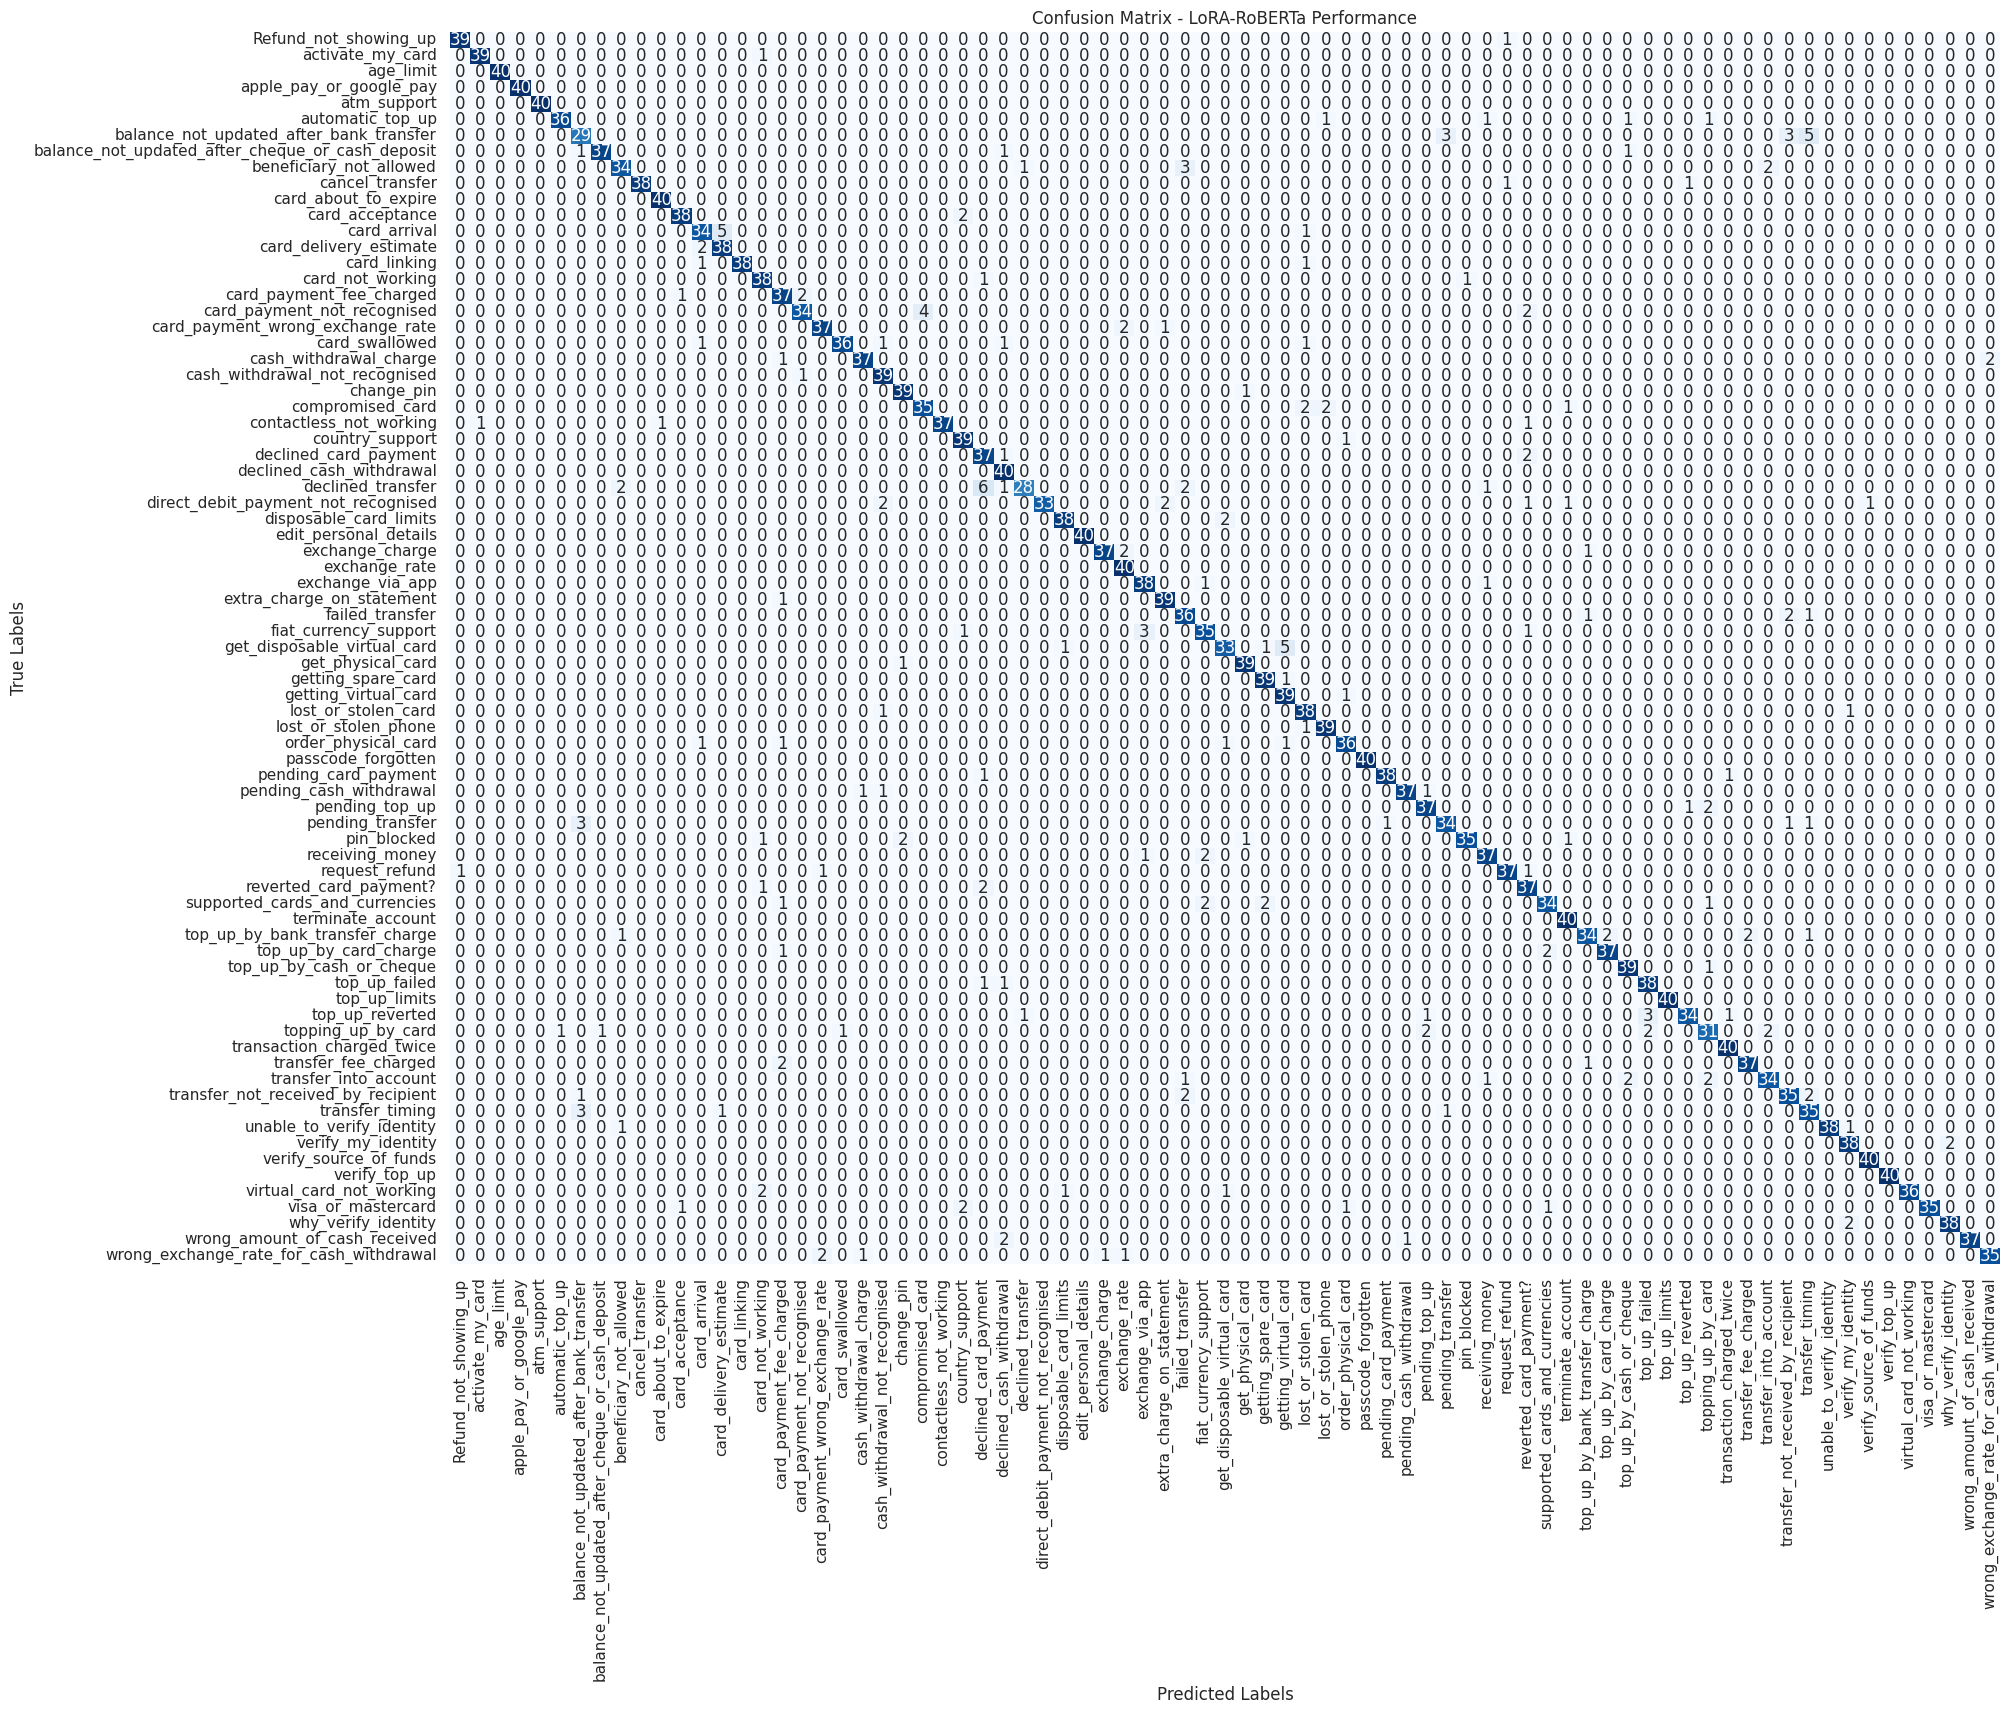

In [ ]:
cm = confusion_matrix(roberta_y_true, roberta_y_pred)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, cbar=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - LoRA-RoBERTa Performance')
plt.show()

The Confusion Matrix reinforces our classification report by showing a strong, clean diagonal line from the top-left to the bottom-right. This diagonal represents correct predictions, and its prominence confirms that ``LoRA-RoBERTa`` successfully identifies the vast majority of banking intents. Unlike the more scattered errors often seen in simpler models, here we see that most classes have near-perfect alignment with their true labels.

While the overall performance is excellent, the small clusters of off-diagonal points reveal where the model faces minor challenges. These typically occur between semantically similar categories—such as different types of ``transfer issues or card status queries`` —where the user's intent is linguistically very close. However, the density of these errors is remarkably low, showing that the transformer architecture's ability to capture context is far more effective than the keyword-based approach of the MLP baseline.

---

## Real-World Application

To show how our model works in a real banking scenario, we will implement a prediction function that includes a data protection layer. This function automatically removes sensitive information like credit card numbers or emails before processing the text. This way, our AI focuses purely on understanding the customer's intent while keeping their personal data secure.

In [ ]:
def predict_text_safe(text, model, tokenizer, label_encoder, device, top_k=3, hash_identifiers=False):
    """
    Predict banking customer intent with automatic PII redaction.
    """
    # Redact or hash PII
    text_cleaned = remove_pii(text, hash_identifiers=hash_identifiers)

    # Tokenize and predict intent
    inputs = tokenizer(text_cleaned, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]

    # Get top-k predictions
    top_probs, top_indices = torch.topk(probs, top_k)

    print(f"Original input: {text}\n")
    print(f"Redacted input: {text_cleaned}\n")
    print(f"Predicted Customer Intent:")

    for i, (prob, idx) in enumerate(zip(top_probs, top_indices), 1):
        category = label_encoder.inverse_transform([idx.item()])[0]
        print(f"{i}. {category}: {prob.item():.4f}")

    return text_cleaned, top_indices[0].item()

In [ ]:
text = """I am currently in Tokyo and I tried to use my card ending in 4455
at a local ATM, but it charged me a very high conversion fee.
Can you explain the exchange rate? My registered email is alice.travels@world.com."""

cleaned_text, predicted_class = predict_text_safe(
    text,
    model=model,
    tokenizer=tokenizer,
    label_encoder=le,
    device=device,
    top_k=3,
    hash_identifiers=True
)

Original input: I am currently in Tokyo and I tried to use my card ending in 4455 
at a local ATM, but it charged me a very high conversion fee. 
Can you explain the exchange rate? My registered email is alice.travels@world.com.

Redacted input: I am currently in Tokyo and I tried to use my card ending in 4455 
at a local ATM, but it charged me a very high conversion fee. 
Can you explain the exchange rate? My registered email is [HASH:a9fbf19cb2438ec8].

Predicted Customer Intent:
1. wrong_exchange_rate_for_cash_withdrawal: 0.9647
2. card_payment_wrong_exchange_rate: 0.0241
3. cash_withdrawal_charge: 0.0034


This test demonstrates the model's high semantic precision by correctly identifying the primary intent as ``wrong_exchange_rate_for_cash_withdrawal`` with a ``96.47% confidence score``. Despite the complexity of the input (mentioning Tokyo, an ATM, and fees), the transformer-based attention mechanism successfully distinguished a "cash withdrawal" issue from a general "card payment" error.

Furthermore, the system maintained strict privacy standards by accurately redacting the user's email while still processing the specific intent. This confirms that the model is not only accurate but also production-ready for secure banking environments.

---

## Conclusion

We have successfully implemented an end-to-end AI workflow for intent classification using the Banking77 dataset. By comparing traditional neural networks with modern transformer-based approaches, we gained practical insights into the performance-efficiency tradeoffs that guide real-world AI implementation decisions.

Beyond model accuracy, we integrated responsible AI best practices by developing comprehensive PII protection strategies to safeguard sensitive customer information. This security layer is a critical requirement for deploying AI systems in highly regulated industries like financial banking, ensuring our solution is not only high-performing but also production-ready and secure.